#### `Import Libraries`

In [1]:
import os
import re
import hashlib
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers,Model,callbacks,optimizers,metrics
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

#### `Read Data`

In [2]:
DATASET_DIR = "Shop DataSet"

non_shop_lifters_dir = os.path.join(DATASET_DIR, "non shop lifters")
shop_lifters_dir = os.path.join(DATASET_DIR, "shop lifters")

In [3]:
def delete_all_suffix_1_files(folder_path):
    print(f"\nChecking folder: {folder_path}")

    video_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".mp4")]
    to_delete = [f for f in video_files if re.search(r"_1\.mp4$", f, re.IGNORECASE)]

    print(f"Files to delete: {len(to_delete)}")

    for f in to_delete:
        file_path = os.path.join(folder_path, f)
        try:
            os.remove(file_path)
            print(f"Deleted: {f}")
        except Exception as e:
            print(f"Error deleting {file_path}: {e}")

In [4]:
delete_all_suffix_1_files(non_shop_lifters_dir)
delete_all_suffix_1_files(shop_lifters_dir)


Checking folder: Shop DataSet\non shop lifters
Files to delete: 220
Deleted: shop_lifter_n_0_1.mp4
Deleted: shop_lifter_n_1.mp4
Deleted: shop_lifter_n_100_1.mp4
Deleted: shop_lifter_n_101_1.mp4
Deleted: shop_lifter_n_102_1.mp4
Deleted: shop_lifter_n_103_1.mp4
Deleted: shop_lifter_n_104_1.mp4
Deleted: shop_lifter_n_105_1.mp4
Deleted: shop_lifter_n_106_1.mp4
Deleted: shop_lifter_n_107_1.mp4
Deleted: shop_lifter_n_108_1.mp4
Deleted: shop_lifter_n_109_1.mp4
Deleted: shop_lifter_n_10_1.mp4
Deleted: shop_lifter_n_110_1.mp4
Deleted: shop_lifter_n_111_1.mp4
Deleted: shop_lifter_n_112_1.mp4
Deleted: shop_lifter_n_113_1.mp4
Deleted: shop_lifter_n_114_1.mp4
Deleted: shop_lifter_n_115_1.mp4
Deleted: shop_lifter_n_116_1.mp4
Deleted: shop_lifter_n_117_1.mp4
Deleted: shop_lifter_n_118_1.mp4
Deleted: shop_lifter_n_119_1.mp4
Deleted: shop_lifter_n_11_1.mp4
Deleted: shop_lifter_n_120_1.mp4
Deleted: shop_lifter_n_121_1.mp4
Deleted: shop_lifter_n_122_1.mp4
Deleted: shop_lifter_n_123_1.mp4
Deleted: shop_l

In [5]:
def count_videos(folder_path):
    video_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".mp4")]
    return len(video_files)

non_count = count_videos(non_shop_lifters_dir)
shop_count = count_videos(shop_lifters_dir)

print("non shop lifters videos:", non_count)
print("shop lifters videos    :", shop_count)
print("Total videos           :", non_count + shop_count)

non shop lifters videos: 311
shop lifters videos    : 319
Total videos           : 630


In [6]:
CLASS_NAMES = ["non shop lifters", "shop lifters"]
CLASS_TO_LABEL = {
    "non shop lifters": 0,
    "shop lifters": 1
}

SEQ_LEN = 32
IMG_SIZE = 128
BATCH_SIZE = 4
SEED = 42

#### `Understand Data`

In [7]:
def collect_video_metadata(dataset_dir, class_names):
    records = []

    for cls in class_names:
        class_dir = os.path.join(dataset_dir, cls)

        if not os.path.exists(class_dir):
            print(f"Folder not found: {class_dir}")
            continue

        for file_name in os.listdir(class_dir):
            file_path = os.path.join(class_dir, file_name)

            if not os.path.isfile(file_path):
                continue

            cap = cv2.VideoCapture(file_path)

            frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            fps = cap.get(cv2.CAP_PROP_FPS)
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

            duration_sec = frames / fps if fps and fps > 0 else 0

            records.append({
                "class": cls,
                "label": CLASS_TO_LABEL[cls],
                "file": file_name,
                "path": file_path,
                "frames": frames,
                "fps": fps,
                "width": width,
                "height": height,
                "duration_sec": duration_sec
            })

            cap.release()

    return pd.DataFrame(records)

df = collect_video_metadata(DATASET_DIR, CLASS_NAMES)
print(df.shape)
df.head()

(630, 9)


,class,label,file,path,frames,fps,width,height,duration_sec
0,non shop lifters,0,shop_lifter_n_0.mp4,Shop DataSet\non shop lifters\shop_lifter_n_0.mp4,450,25.0,704,576,18.0
1,non shop lifters,0,shop_lifter_n_10.mp4,Shop DataSet\non shop lifters\shop_lifter_n_10...,475,25.0,704,576,19.0
2,non shop lifters,0,shop_lifter_n_100.mp4,Shop DataSet\non shop lifters\shop_lifter_n_10...,400,25.0,704,576,16.0
3,non shop lifters,0,shop_lifter_n_101.mp4,Shop DataSet\non shop lifters\shop_lifter_n_10...,300,25.0,704,576,12.0
4,non shop lifters,0,shop_lifter_n_102.mp4,Shop DataSet\non shop lifters\shop_lifter_n_10...,275,25.0,704,576,11.0


In [8]:
print(df["class"].value_counts())
print()
print(df.describe(include="all"))

class
shop lifters        319
non shop lifters    311
Name: count, dtype: int64

               class       label                file  \
count            630  630.000000                 630   
unique             2         NaN                 575   
top     shop lifters         NaN  videppppsss_40.mp4   
freq             319         NaN                   2   
mean             NaN    0.506349                 NaN   
std              NaN    0.500357                 NaN   
min              NaN    0.000000                 NaN   
25%              NaN    0.000000                 NaN   
50%              NaN    1.000000                 NaN   
75%              NaN    1.000000                 NaN   
max              NaN    1.000000                 NaN   

                                                     path       frames  \
count                                                 630   630.000000   
unique                                                630          NaN   
top     Shop DataSet\sho

#### `Visualization`

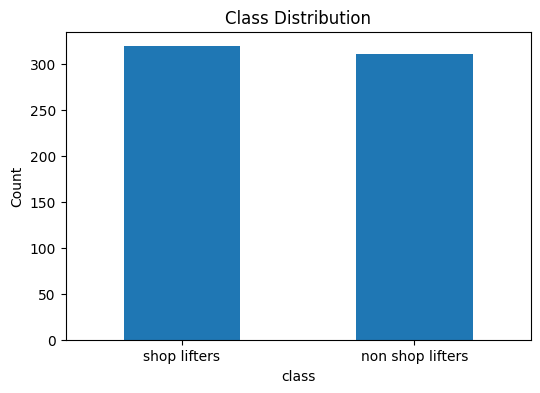

In [9]:
plt.figure(figsize=(6,4))
df["class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

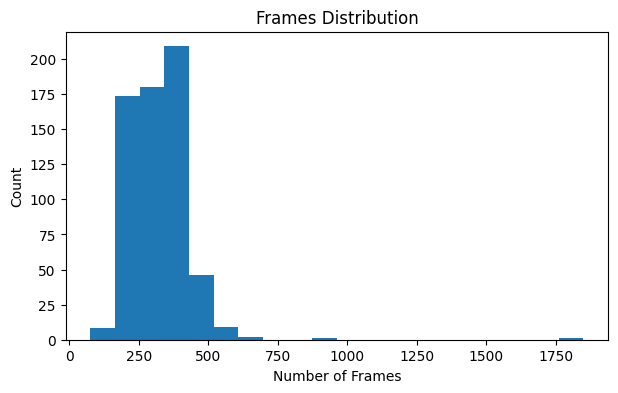

In [10]:
plt.figure(figsize=(7,4))
plt.hist(df["frames"], bins=20)
plt.title("Frames Distribution")
plt.xlabel("Number of Frames")
plt.ylabel("Count")
plt.show()

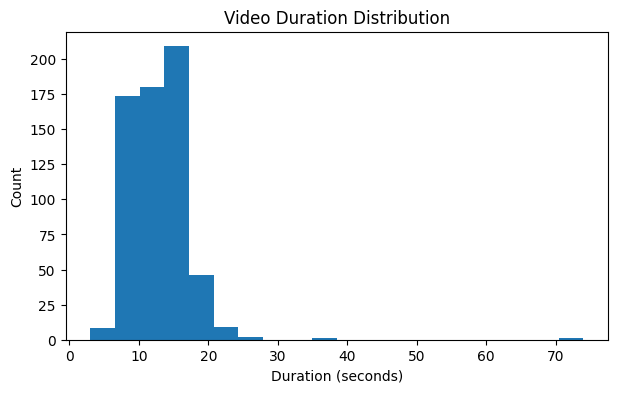

In [11]:
plt.figure(figsize=(7,4))
plt.hist(df["duration_sec"], bins=20)
plt.title("Video Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()

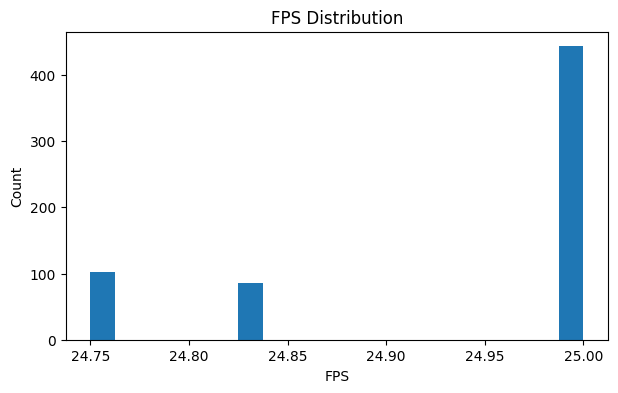

In [12]:
plt.figure(figsize=(7,4))
plt.hist(df["fps"], bins=20)
plt.title("FPS Distribution")
plt.xlabel("FPS")
plt.ylabel("Count")
plt.show()

In [13]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (441, 9)
Val  : (94, 9)
Test : (95, 9)


In [14]:
def show_sample_frames(video_path, num_frames=6):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        print("Cannot read video.")
        cap.release()
        return

    indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()
        if success:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

    cap.release()

    plt.figure(figsize=(15, 4))
    for i, frame in enumerate(frames):
        plt.subplot(1, len(frames), i + 1)
        plt.imshow(frame)
        plt.title(f"Frame {indices[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

Shop DataSet\non shop lifters\shop_lifter_n_0.mp4


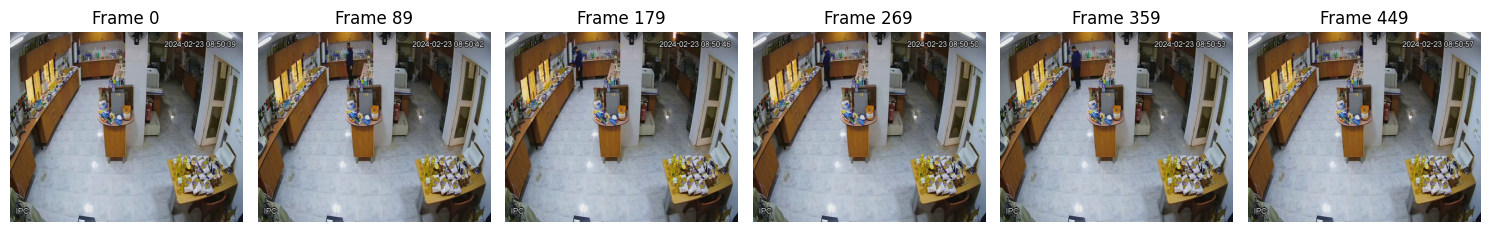

In [16]:
sample_path = df.iloc[0]["path"]
print(sample_path)
show_sample_frames(sample_path, num_frames=6)

#### `Preprocessing`

In [17]:
def uniform_frame_sampling(video_path, seq_len=32, img_size=128):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return np.zeros((seq_len, img_size, img_size, 3), dtype=np.float32)

    indices = np.linspace(0, total_frames - 1, seq_len).astype(int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()

        if not success:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))

        frames.append(frame)

    cap.release()
    frames = np.array(frames, dtype=np.float32)
    return frames

In [ ]:
def augment_video_frames(frames):
    augmented = frames.copy()

    if random.random() < 0.5:
        augmented = np.array([cv2.flip(f, 1) for f in augmented])

    if random.random() < 0.5:
        factor = random.uniform(0.8, 1.2)
        augmented = np.clip(augmented * factor, 0, 255)

    if random.random() < 0.3:
        angle = random.uniform(-10, 10)
        h, w = augmented[0].shape[:2]
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)

        rotated_frames = []
        for f in augmented:
            rotated = cv2.warpAffine(
                f, M, (w, h),
                borderMode=cv2.BORDER_REFLECT_101
            )
            rotated_frames.append(rotated)

        augmented = np.array(rotated_frames)

    return augmented.astype(np.float32)

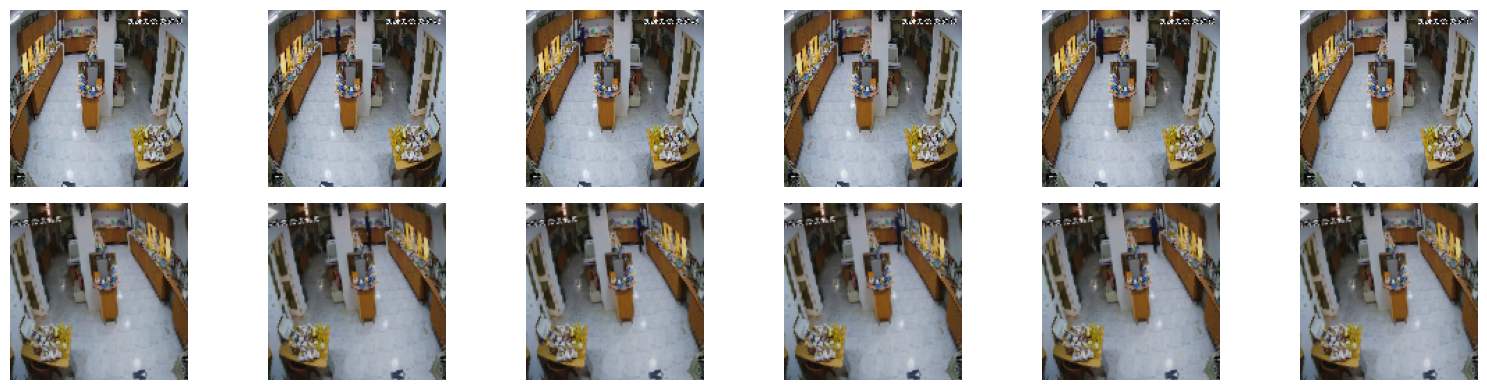

In [19]:
def show_original_vs_augmented(video_path, seq_len=32, img_size=128):
    original = uniform_frame_sampling(video_path, seq_len=seq_len, img_size=img_size)
    augmented = augment_video_frames(original)

    plt.figure(figsize=(16, 4))
    for i in range(seq_len):
        plt.subplot(2, seq_len, i + 1)
        plt.imshow(original[i].astype(np.uint8))
        plt.axis("off")
        if i == 0:
            plt.ylabel("Original", fontsize=12)

        plt.subplot(2, seq_len, seq_len + i + 1)
        plt.imshow(augmented[i].astype(np.uint8))
        plt.axis("off")
        if i == 0:
            plt.ylabel("Augmented", fontsize=12)

    plt.tight_layout()
    plt.show()

show_original_vs_augmented(sample_path, seq_len=6, img_size=IMG_SIZE)

In [20]:
def preprocess_video(video_path, seq_len=32, img_size=128, augment=False):
    frames = uniform_frame_sampling(video_path, seq_len=seq_len, img_size=img_size)

    if augment:
        frames = augment_video_frames(frames)

    frames = frames / 255.0
    return frames.astype(np.float32)

In [21]:
class VideoDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=4, seq_len=32, img_size=128, augment=False, shuffle=True):
        self.df = df.reset_index(drop=True).copy()
        self.batch_size = batch_size
        self.seq_len = seq_len
        self.img_size = img_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size : (index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indices]

        X_batch = []
        y_batch = []

        for _, row in batch_df.iterrows():
            video = preprocess_video(
                row["path"],
                seq_len=self.seq_len,
                img_size=self.img_size,
                augment=self.augment
            )
            X_batch.append(video)
            y_batch.append(row["label"])

        X_batch = np.array(X_batch, dtype=np.float32)
        y_batch = np.array(y_batch, dtype=np.float32)

        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [22]:
train_gen = VideoDataGenerator(
    train_df,
    batch_size=BATCH_SIZE,
    seq_len=SEQ_LEN,
    img_size=IMG_SIZE,
    augment=True,
    shuffle=True
)

val_gen = VideoDataGenerator(
    val_df,
    batch_size=BATCH_SIZE,
    seq_len=SEQ_LEN,
    img_size=IMG_SIZE,
    augment=False,
    shuffle=False
)

test_gen = VideoDataGenerator(
    test_df,
    batch_size=BATCH_SIZE,
    seq_len=SEQ_LEN,
    img_size=IMG_SIZE,
    augment=False,
    shuffle=False
)

print("Train steps:", len(train_gen))
print("Val steps  :", len(val_gen))
print("Test steps :", len(test_gen))

Train steps: 111
Val steps  : 24
Test steps : 24


In [23]:
X_batch, y_batch = train_gen[0]
print("X_batch:", X_batch.shape)
print("y_batch:", y_batch.shape)
print("range:", X_batch.min(), X_batch.max())

X_batch: (4, 32, 128, 128, 3)
y_batch: (4,)
range: 0.0 1.0


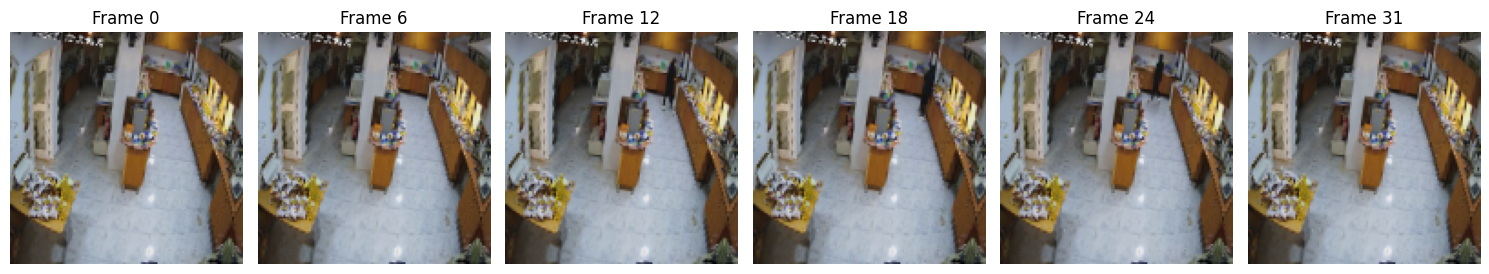

Label: 1.0


In [24]:
def show_preprocessed_video(video_tensor, num_frames=6):
    indices = np.linspace(0, len(video_tensor) - 1, num_frames).astype(int)

    plt.figure(figsize=(15, 4))
    for i, idx in enumerate(indices):
        plt.subplot(1, num_frames, i + 1)
        plt.imshow(video_tensor[idx])
        plt.title(f"Frame {idx}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_preprocessed_video(X_batch[0], num_frames=6)
print("Label:", y_batch[0])

#### `Model`

In [25]:
input_shape = (32, 128, 128, 3)

model = models.Sequential([
    layers.Conv3D(32, kernel_size=(3, 3, 3), activation='relu', padding='same', input_shape=input_shape),
    layers.MaxPooling3D(pool_size=(1, 2, 2)),

    layers.Conv3D(64, kernel_size=(3, 3, 3), activation='relu', padding='same'),
    layers.Dropout(0.3),
    layers.MaxPooling3D(pool_size=(2, 2, 2)),

    layers.Conv3D(128, kernel_size=(3, 3, 3), activation='relu', padding='same'),
    layers.Dropout(0.4),
    layers.MaxPooling3D(pool_size=(2, 2, 2)),

    layers.Conv3D(256, kernel_size=(3, 3, 3), activation='relu', padding='same'),
    layers.Dropout(0.4),
    layers.MaxPooling3D(pool_size=(2, 2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

c:\Users\moham\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 32, 128, 128,   │         2,624 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 32, 64, 64, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 32, 64, 64, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 64, 64, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 16, 32, 32, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 16, 32, 32,     │       221,312 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 32, 32,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 8, 16, 16, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 8, 16, 16, 256) │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 16, 16, 256) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_3 (MaxPooling3D)  │ (None, 4, 8, 8, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,719,745 (132.45 MB)

 Trainable params: 34,719,745 (132.45 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', metrics.Precision(), metrics.Recall(),metrics.AUC(name='auc')]
)

In [27]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    "model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[checkpoint_callback]
)

c:\Users\moham\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4900 - auc: 0.4894 - loss: 0.7508 - precision: 0.5269 - recall: 0.5795
Epoch 1: val_accuracy improved from None to 0.48936, saving model to model.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 603s 5s/step - accuracy: 0.5034 - auc: 0.5134 - loss: 0.7419 - precision: 0.5091 - recall: 0.5022 - val_accuracy: 0.4894 - val_auc: 0.7043 - val_loss: 0.6919 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4534 - auc: 0.4380 - loss: 0.7265 - precision: 0.4888 - recall: 0.5966
Epoch 2: val_accuracy improved from 0.48936 to 0.78723, saving model to model.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 576s 5s/step - accuracy: 0.4921 - auc: 0.4786 - loss: 0.7144 - precision: 0.4980 - recall: 0.5561 - val_accuracy: 0.7872 - val_auc: 0.6449 - val_loss: 0.6912 - val_precision: 0.7593 - val_recall: 0.8542
Epoch 3/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5264 - auc: 0.5105 - loss:

In [28]:
model.save('model.keras')

In [29]:
best_model = load_model('model.keras')

test_results = best_model.evaluate(test_gen)

loss, accuracy, precision, recall, auc = test_results

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test AUC: {auc:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.9263 - auc: 0.9546 - loss: 0.4298 - precision: 0.8727 - recall: 1.0000
Test Loss: 0.4298
Test Accuracy: 0.9263
Test Precision: 0.8727
Test Recall: 1.0000
Test AUC: 0.9546


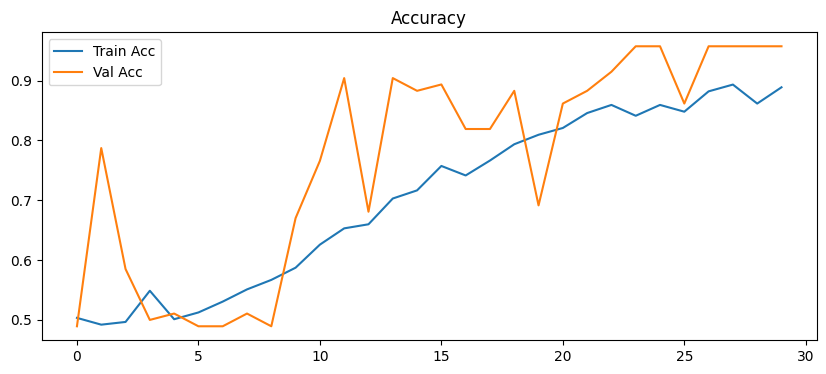

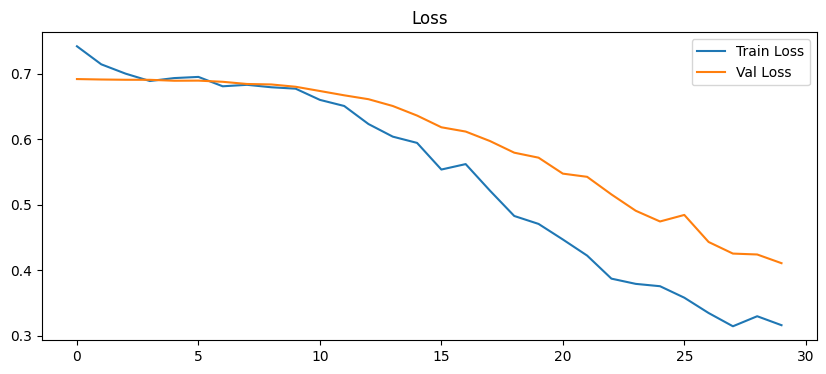

In [30]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()
plt.show()

In [31]:
y_pred_prob = model.predict(test_gen, verbose=1).flatten()
y_pred = (y_pred_prob > 0.5).astype(np.int32)

y_true = test_df["label"].values[:len(y_pred)]

print(classification_report(
    y_true,
    y_pred,
    target_names=["non shop lifters", "shop lifters"]
))

24/24 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step
                  precision    recall  f1-score   support

non shop lifters       1.00      0.85      0.92        47
    shop lifters       0.87      1.00      0.93        48

        accuracy                           0.93        95
       macro avg       0.94      0.93      0.93        95
    weighted avg       0.94      0.93      0.93        95



[[40  7]
 [ 0 48]]


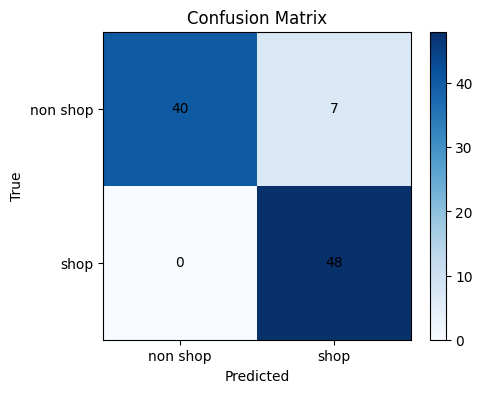

In [32]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["non shop", "shop"])
plt.yticks([0,1], ["non shop", "shop"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [34]:
def predict_single_video(model, video_path, seq_len=32, img_size=128):
    video = preprocess_video(video_path, seq_len=seq_len, img_size=img_size, augment=False)
    x = np.expand_dims(video, axis=0)
    prob = model.predict(x, verbose=0)[0][0]
    label = 1 if prob > 0.5 else 0
    class_name = "shop lifters" if label == 1 else "non shop lifters"
    return prob, label, class_name

sample_video = test_df.iloc[0]["path"]
prob, label, class_name = predict_single_video(model, sample_video, seq_len=SEQ_LEN, img_size=IMG_SIZE)

print("Video:", sample_video)
print("Probability:", prob)
print("Predicted label:", label)
print("Predicted class:", class_name)

Video: Shop DataSet\shop lifters\shop_lifter_88.mp4
Probability: 0.59623986
Predicted label: 1
Predicted class: shop lifters


In [37]:
def predict_single_video(model, video_path, seq_len=32, img_size=128):
    video = preprocess_video(video_path, seq_len=seq_len, img_size=img_size, augment=False)
    x = np.expand_dims(video, axis=0)
    prob = model.predict(x, verbose=0)[0][0]
    label = 1 if prob > 0.5 else 0
    class_name = "shop lifters" if label == 1 else "non shop lifters"
    return prob, label, class_name

sample_video = test_df.iloc[5]["path"]
prob, label, class_name = predict_single_video(model, sample_video, seq_len=SEQ_LEN, img_size=IMG_SIZE)

print("Video:", sample_video)
print("Probability:", prob)
print("Predicted label:", label)
print("Predicted class:", class_name)

Video: Shop DataSet\non shop lifters\shop_lifter_n_2.mp4
Probability: 0.25046137
Predicted label: 0
Predicted class: non shop lifters
